In [1]:
# ppo_subset_training.py
import os
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt

# make sure these imports point to where your classes live
from environment.subset_selector.train import Train_SubsetSelectorEnv
from environment.subset_selector.eval import Eval_SubsetSelectorEnv

In [2]:
# device
device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if torch.backends.mps.is_available() else "cpu")

# reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
# Plot
def plot_learning_curve(scores, file='curves/ppo.png'):
    plt.plot(scores)
    plt.xlabel("Evaluation Iteration")
    plt.ylabel("Avg Reward")
    plt.title("PPO Evaluation Curve")
    plt.grid()
    plt.savefig(file)
    plt.show()

In [4]:
# ----------------------------
# Reuse your flatten_obs definition (adjust if needed)
def flatten_obs(obs):
    gpu_state = obs['gpu_state'].flatten()
    current_job = np.concatenate([obs['current_job']['one_hot'], [obs['current_job']['batch_size']]])
    future_stats = obs['future_job_stats'].flatten()
    jobs_left = np.array([obs['jobs_left']], dtype=np.float32)  # Normalized
    return np.concatenate([gpu_state, current_job, future_stats, jobs_left])

# ----------------------------
# Memory
class PPOMemory():
    def __init__(self, batch_size):
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.values = []
        self.dones = []
        self.batch_size = batch_size

    def store(self, state, action, log_prob, value, reward, done):
        self.states.append(state)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.values.append(value)
        self.rewards.append(reward)
        self.dones.append(done)

    def generate_batches(self):
        n = len(self.states)
        indices = np.arange(n)
        np.random.shuffle(indices)
        if n == 0:
            return (np.array([]),)*7
        batch_starts = np.arange(0, n, self.batch_size)
        batches = [indices[i:i+self.batch_size] for i in batch_starts]
        return (
            np.array(self.states),
            np.array(self.actions),
            np.array(self.log_probs),
            np.array(self.values),
            np.array(self.rewards),
            np.array(self.dones),
            batches
        )

    def clear(self):
        self.__init__(self.batch_size)


In [5]:
# ----------------------------
# Actor & Critic (small changes: no softmax-probs returned directly, but a Categorical dist)
class ActorNet(nn.Module):
    def __init__(self, input_dim, output_dim, lr, checkpoint_file,
                 hidden_size=256, dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_size)
        self.drop1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.drop2 = nn.Dropout(dropout)
        self.fc3 = nn.Linear(hidden_size, output_dim)
        self.checkpoint_file = checkpoint_file
        self.optimizer = optim.Adam(self.parameters(), lr=lr)
        self.to(device)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.drop1(x)
        x = F.relu(self.fc2(x))
        x = self.drop2(x)
        logits = self.fc3(x)
        probs = F.softmax(logits, dim=-1)
        dist = Categorical(probs)
        return dist, probs

    def save(self):
        os.makedirs(os.path.dirname(self.checkpoint_file), exist_ok=True)
        torch.save(self.state_dict(), self.checkpoint_file)

    def load(self):
        self.load_state_dict(torch.load(self.checkpoint_file, map_location=device))

class CriticNet(nn.Module):
    def __init__(self, input_dim, lr, checkpoint_file,
                 hidden_size=256, dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_size)
        self.drop1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.drop2 = nn.Dropout(dropout)
        self.fc3 = nn.Linear(hidden_size, 1)
        self.checkpoint_file = checkpoint_file
        self.optimizer = optim.Adam(self.parameters(), lr=lr)
        self.to(device)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.drop1(x)
        x = F.relu(self.fc2(x))
        x = self.drop2(x)
        value = self.fc3(x)
        return value

    def save(self):
        os.makedirs(os.path.dirname(self.checkpoint_file), exist_ok=True)
        torch.save(self.state_dict(), self.checkpoint_file)

    def load(self):
        self.load_state_dict(torch.load(self.checkpoint_file, map_location=device))

In [6]:
# ----------------------------
# PPO Agent
class PPOAgent:
    def __init__(self, state_dim, action_dim, lr_actor, lr_critic, gamma, lamda,
                 clip, epochs, batch_size, ent_start=0.01, ent_end=0.0, ent_decay=0.995):
        self.gamma = gamma
        self.lamda = lamda
        self.clip = clip
        self.epochs = epochs
        self.ent_coef = ent_start
        self.ent_end = ent_end
        self.ent_decay = ent_decay

        self.actor = ActorNet(state_dim, action_dim, lr_actor, 'models/subset_selector/ppo/actor.pth')
        self.critic = CriticNet(state_dim, lr_critic, 'models/subset_selector/ppo/critic.pth')
        self.memory = PPOMemory(batch_size)

    def choose_action(self, state):
        state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        dist, _ = self.actor(state_t)
        action = dist.sample()
        logp = dist.log_prob(action).item()
        val = self.critic(state_t).squeeze().item()
        return action.item(), logp, val

    def store(self, *args):
        self.memory.store(*args)

    def learn(self):
        states, actions, old_logp, vals, rewards, dones, batches = self.memory.generate_batches()
        if len(states) == 0:
            return
        # Compute advantages with GAE
        advantages = np.zeros_like(rewards, dtype=float)
        gae = 0.0
        for t in reversed(range(len(rewards))):
            next_val = 0 if t == len(rewards)-1 else vals[t+1]
            mask = 1 - dones[t]
            delta = rewards[t] + self.gamma * next_val * mask - vals[t]
            gae = delta + self.gamma * self.lamda * mask * gae
            advantages[t] = gae
        advantages = torch.tensor(advantages, dtype=torch.float32, device=device)
        vals_t = torch.tensor(vals, dtype=torch.float32, device=device)
        old_logp_t = torch.tensor(old_logp, dtype=torch.float32, device=device)

        for _ in range(self.epochs):
            for batch in batches:
                st = torch.tensor(states[batch], dtype=torch.float32, device=device)
                ac = torch.tensor(actions[batch], device=device)
                new_dist, _ = self.actor(st)
                new_logp = new_dist.log_prob(ac)
                ratio = (new_logp - old_logp_t[batch]).exp()
                surr1 = ratio * advantages[batch]
                surr2 = torch.clamp(ratio, 1-self.clip, 1+self.clip) * advantages[batch]
                entropy = new_dist.entropy().mean()
                actor_loss = -torch.min(surr1, surr2).mean() - self.ent_coef * entropy

                ret = advantages[batch] + vals_t[batch]
                critic_val = self.critic(st).squeeze()
                # critic_loss = F.mse_loss(critic_val, ret)
                critic_loss = F.mse_loss(critic_val.squeeze(), ret.squeeze())

                loss = actor_loss + 0.5 * critic_loss

                self.actor.optimizer.zero_grad()
                self.critic.optimizer.zero_grad()
                loss.backward()
                self.actor.optimizer.step()
                self.critic.optimizer.step()

        self.memory.clear()
        self.ent_coef = max(self.ent_end, self.ent_coef * self.ent_decay)

    def save(self):
        self.actor.save(); self.critic.save()

    def load(self):
        self.actor.load(); self.critic.load()

In [7]:
# ----------------------------
# Evaluation (simple)
def evaluate_model(agent, env, episodes=20):
    agent.actor.eval()
    rewards = []
    
    total_sum = []
    
    for _ in range(episodes):
        obs, _ = env.reset()
        st = flatten_obs(obs)
        done = False
        total = 0.0
        while not done:
            a, _, _ = agent.choose_action(st)
            obs, reward, term, trunc, info = env.step(int(a))
            total += reward
            done = term or trunc
            st = flatten_obs(obs) if not done else None
        
        total_sum.append(info["total_reward"])
        rewards.append(total)
    agent.actor.train()
    return np.mean(rewards), rewards, np.mean(total_sum)


In [8]:
# ----------------------------
# Training loop for subset selection
def train_ppo(
    n_episodes=2000, eval_interval=20, eval_episodes=20,
    lr_actor=3e-4, lr_critic=1e-3, gamma=0.99, lamda=0.95,
    clip=0.2, epochs=4, batch_size=32
):
    # envs
    train_env = Train_SubsetSelectorEnv()
    eval_env = Eval_SubsetSelectorEnv("saved_job_sets")

    # state/action dims (assume reset returns obs, {})
    obs, _ = train_env.reset()
    state_dim = flatten_obs(obs).shape[0]
    action_dim = train_env.action_space.n  # should be 2

    agent = PPOAgent(
        state_dim, action_dim, lr_actor, lr_critic, gamma, lamda,
        clip, epochs, batch_size
    )

    best_eval = -float('inf')
    eval_scores = []
    eval_total_sum = []

    for ep in range(1, n_episodes+1):
        obs, _ = train_env.reset()
        st = flatten_obs(obs)
        done = False
        ep_reward = 0.0

        while not done:
            a_idx, logp, val = agent.choose_action(st)
            next_obs, reward, term, trunc, info = train_env.step(int(a_idx))            
            done = term or trunc
            reward_float = float(reward)
            agent.store(st, a_idx, logp, val, reward_float, done)
            ep_reward += reward_float
            st = flatten_obs(next_obs) if not done else None

        # learn at end of episode
        agent.learn()
        agent.save()

        
        if ep % eval_interval == 0:
            mean_reward, rewards, total_sum = evaluate_model(agent, eval_env, episodes=eval_episodes)
            eval_scores.append(mean_reward)
            eval_total_sum.append(total_sum)
            print(f"[EP {ep}] || eval_mean={mean_reward:.3f} || total_sum={total_sum:.3f}")

    return agent, eval_scores, eval_total_sum

[EP 20] || eval_mean=0.028 || total_sum=9.928
[EP 40] || eval_mean=0.070 || total_sum=9.875
[EP 60] || eval_mean=-0.021 || total_sum=11.019
[EP 80] || eval_mean=-0.138 || total_sum=9.981
[EP 100] || eval_mean=0.105 || total_sum=10.420
[EP 120] || eval_mean=0.349 || total_sum=10.470
[EP 140] || eval_mean=-0.059 || total_sum=9.455
[EP 160] || eval_mean=0.534 || total_sum=10.149
[EP 180] || eval_mean=-0.087 || total_sum=9.898
[EP 200] || eval_mean=0.208 || total_sum=10.848
[EP 220] || eval_mean=0.058 || total_sum=10.133
[EP 240] || eval_mean=-0.023 || total_sum=9.727
[EP 260] || eval_mean=-0.108 || total_sum=10.506
[EP 280] || eval_mean=0.209 || total_sum=9.890
[EP 300] || eval_mean=0.889 || total_sum=9.394
[EP 320] || eval_mean=-0.099 || total_sum=9.874
[EP 340] || eval_mean=0.233 || total_sum=10.409
[EP 360] || eval_mean=0.161 || total_sum=9.905
[EP 380] || eval_mean=-0.388 || total_sum=9.242
[EP 400] || eval_mean=0.318 || total_sum=10.650
[EP 420] || eval_mean=-0.498 || total_sum=9.343

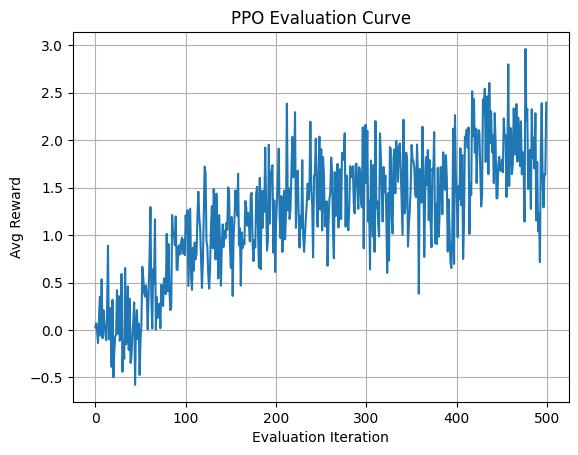

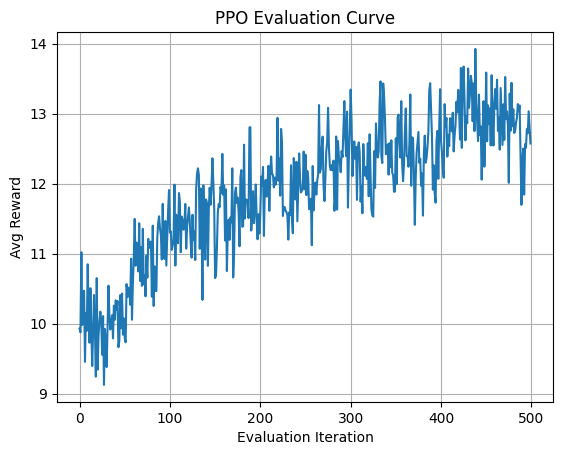

In [9]:
agent, eval_scores, eval_total_sum = train_ppo(
    n_episodes=10000,
    eval_interval=20,
    eval_episodes=20,
    lr_actor=1e-4,
    lr_critic=1e-3,
    clip=0.2,
    epochs=4,
    batch_size=32
)

plot_learning_curve(eval_scores, file='curves/subset_selector/training_ppo.png')
plot_learning_curve(eval_total_sum, file='curves/eval_total_sum.png')


In [10]:
# Save scores to a JSON file
with open('curves/subset_selector/training_ppo.json', 'w') as f:
    json.dump(eval_scores, f)
    
# Save scores to a JSON file
with open('curves/eval_total_sum.json', 'w') as f:
    json.dump(eval_total_sum, f)